In [4]:
def y(x):
    return (x*x + 1)**3

def dy_dx_chainrule(x):
    u = x*x + 1          # g(x)
    du_dx = 2*x          # g'(x)
    dy_du = 3*(u**2)     # f'(u)
    return dy_du * du_dx

for x in [0.0, 1.0, 2.0, -1.5]:
    print(x, y(x), dy_dx_chainrule(x))


0.0 1.0 0.0
1.0 8.0 24.0
2.0 125.0 300.0
-1.5 34.328125 -95.0625


In [3]:
def numeric_grad(f, x, eps=1e-6):
    return (f(x+eps) - f(x-eps)) / (2*eps)

for x in [0.0, 1.0, 2.0, -1.5]:
    print("x =", x)
    print(" chain rule:", dy_dx_chainrule(x))
    print(" numeric   :", numeric_grad(y, x))
    print()



x = 0.0
 chain rule: 0.0
 numeric   : 0.0

x = 1.0
 chain rule: 24.0
 numeric   : 24.000000000690136

x = 2.0
 chain rule: 300.0
 numeric   : 300.00000000995897

x = -1.5
 chain rule: -95.0625
 numeric   : -95.06249999091665



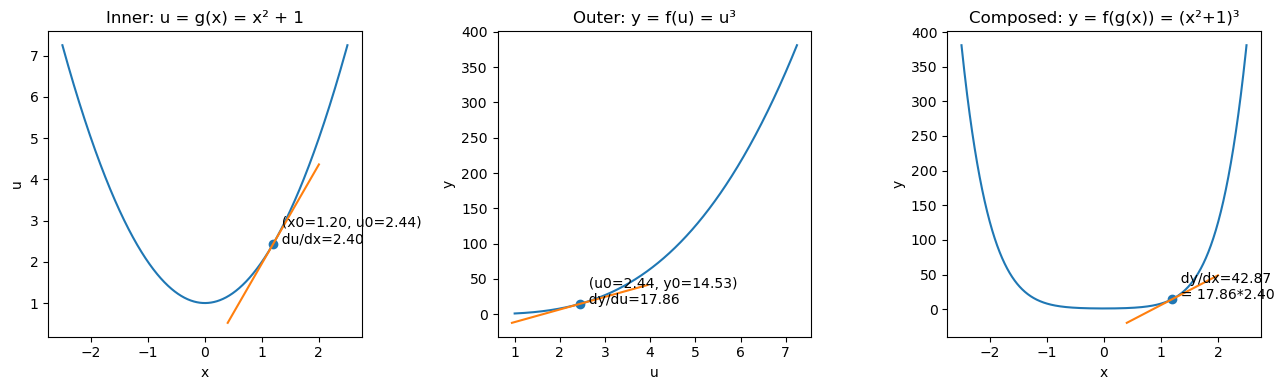

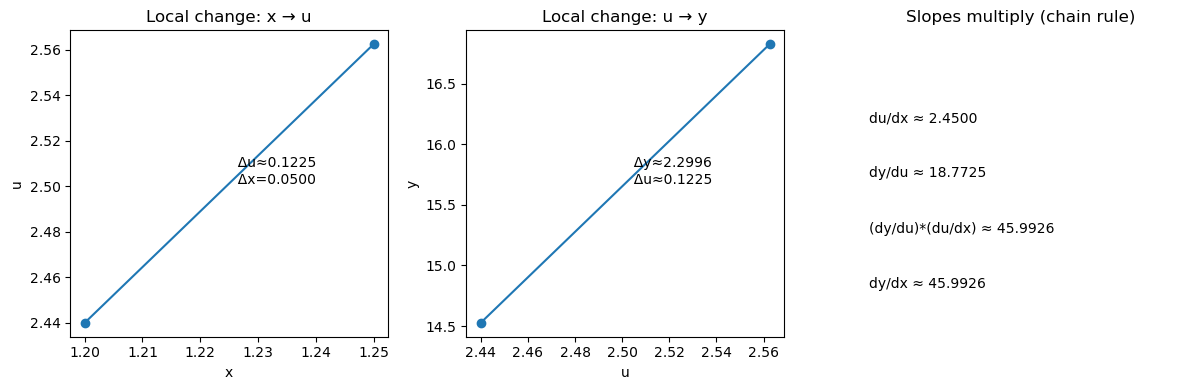

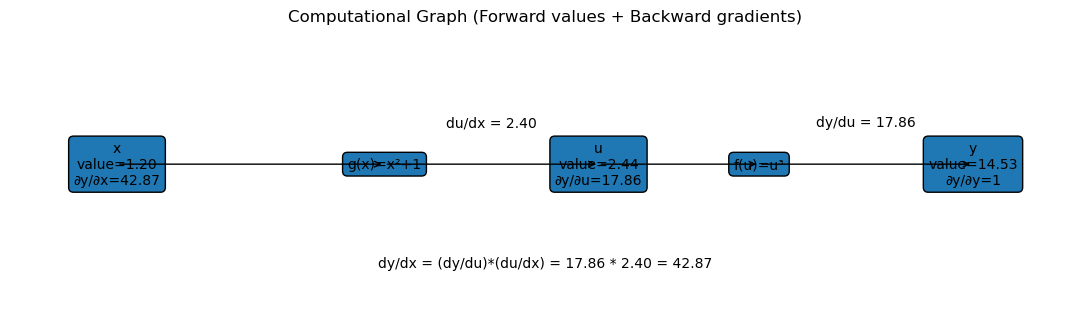

=== Simple exam explanation log ===
u = x^2 + 1 = 2.440000
y = u^3     = 14.526784
du/dx = 2x  = 2.400000
dy/du = 3u^2= 17.860800
dy/dx = (dy/du)*(du/dx) = 42.865920
numeric dy/dx ≈ 42.865920


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# --- Example: y = (x^2 + 1)^3 = f(g(x)) ---
def g(x):      # inner
    return x**2 + 1

def f(u):      # outer
    return u**3

def y(x):
    return f(g(x))

def g_prime(x):
    return 2*x

def f_prime(u):
    return 3*u**2

def dy_dx_chain(x):
    u = g(x)
    return f_prime(u) * g_prime(x)

def numeric_grad(func, x, eps=1e-6):
    return (func(x + eps) - func(x - eps)) / (2*eps)

x0 = 1.2
u0 = g(x0)
y0 = y(x0)

slope_g = g_prime(x0)         # du/dx
slope_f = f_prime(u0)         # dy/du
slope_y = dy_dx_chain(x0)     # dy/dx

xs = np.linspace(-2.5, 2.5, 800)
ys = y(xs)

# --- Figure 1: inner, outer, composed ---
fig = plt.figure(figsize=(13, 4))

ax1 = fig.add_subplot(1, 3, 1)
ax1.plot(xs, g(xs))
ax1.set_title("Inner: u = g(x) = x² + 1")
ax1.set_xlabel("x"); ax1.set_ylabel("u")

dx = 0.8
x_line = np.array([x0 - dx, x0 + dx])
u_line = u0 + slope_g * (x_line - x0)
ax1.plot(x_line, u_line)
ax1.scatter([x0], [u0])
ax1.text(x0, u0, f"  (x0={x0:.2f}, u0={u0:.2f})\n  du/dx={slope_g:.2f}")

ax2 = fig.add_subplot(1, 3, 2)
u_grid = np.linspace(g(xs).min(), g(xs).max(), 800)
ax2.plot(u_grid, f(u_grid))
ax2.set_title("Outer: y = f(u) = u³")
ax2.set_xlabel("u"); ax2.set_ylabel("y")

du = 1.5
u_line2 = np.array([u0 - du, u0 + du])
y_line2 = y0 + slope_f * (u_line2 - u0)
ax2.plot(u_line2, y_line2)
ax2.scatter([u0], [y0])
ax2.text(u0, y0, f"  (u0={u0:.2f}, y0={y0:.2f})\n  dy/du={slope_f:.2f}")

ax3 = fig.add_subplot(1, 3, 3)
ax3.plot(xs, ys)
ax3.set_title("Composed: y = f(g(x)) = (x²+1)³")
ax3.set_xlabel("x"); ax3.set_ylabel("y")

y_line3 = y0 + slope_y * (x_line - x0)
ax3.plot(x_line, y_line3)
ax3.scatter([x0], [y0])
ax3.text(x0, y0, f"  dy/dx={slope_y:.2f}\n  = {slope_f:.2f}*{slope_g:.2f}")

plt.tight_layout()
plt.show()

# --- Figure 2: small deltas show multiplication ---
dx_small = 0.05
x1 = x0 + dx_small
u1 = g(x1)
y1 = y(x1)

fig2 = plt.figure(figsize=(12, 4))

ax = fig2.add_subplot(1, 3, 1)
ax.set_title("Local change: x → u")
ax.set_xlabel("x"); ax.set_ylabel("u")
ax.plot([x0, x1], [u0, u1], marker="o")
ax.text((x0+x1)/2, (u0+u1)/2, f"  Δu≈{(u1-u0):.4f}\n  Δx={dx_small:.4f}")

ax = fig2.add_subplot(1, 3, 2)
ax.set_title("Local change: u → y")
ax.set_xlabel("u"); ax.set_ylabel("y")
ax.plot([u0, u1], [y0, y1], marker="o")
ax.text((u0+u1)/2, (y0+y1)/2, f"  Δy≈{(y1-y0):.4f}\n  Δu≈{(u1-u0):.4f}")

ax = fig2.add_subplot(1, 3, 3)
ax.set_title("Slopes multiply (chain rule)")
ax.axis("off")

approx_du_dx = (u1 - u0) / (x1 - x0)
approx_dy_du = (y1 - y0) / (u1 - u0)
approx_dy_dx = (y1 - y0) / (x1 - x0)

ax.text(0.02, 0.70, f"du/dx ≈ {approx_du_dx:.4f}")
ax.text(0.02, 0.52, f"dy/du ≈ {approx_dy_du:.4f}")
ax.text(0.02, 0.34, f"(dy/du)*(du/dx) ≈ {approx_dy_du*approx_du_dx:.4f}")
ax.text(0.02, 0.16, f"dy/dx ≈ {approx_dy_dx:.4f}")

plt.tight_layout()
plt.show()

# --- Figure 3: computational graph (backprop style) ---
x = x0
u = g(x)
y_val = f(u)

dy_du = f_prime(u)
du_dx = g_prime(x)
dy_dx = dy_du * du_dx

fig3 = plt.figure(figsize=(11, 3.2))
ax = fig3.add_subplot(1, 1, 1)
ax.set_title("Computational Graph (Forward values + Backward gradients)")
ax.axis("off")

pos = {"x": (0.1, 0.5), "g": (0.35, 0.5), "u": (0.55, 0.5), "f": (0.70, 0.5), "y": (0.90, 0.5)}

def node(xy, text):
    ax.text(xy[0], xy[1], text, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.35"))

def arrow(a, b, label):
    ax.annotate("", xy=pos[b], xytext=pos[a], arrowprops=dict(arrowstyle="->"))
    mid = ((pos[a][0] + pos[b][0]) / 2, (pos[a][1] + pos[b][1]) / 2)
    ax.text(mid[0], mid[1] + 0.14, label, ha="center")

node(pos["x"], f"x\nvalue={x:.2f}\n∂y/∂x={dy_dx:.2f}")
node(pos["g"], "g(x)=x²+1")
node(pos["u"], f"u\nvalue={u:.2f}\n∂y/∂u={dy_du:.2f}")
node(pos["f"], "f(u)=u³")
node(pos["y"], f"y\nvalue={y_val:.2f}\n∂y/∂y=1")

arrow("x", "g", "")
arrow("g", "u", f"du/dx = {du_dx:.2f}")
arrow("u", "f", "")
arrow("f", "y", f"dy/du = {dy_du:.2f}")

ax.text(0.5, 0.12, f"dy/dx = (dy/du)*(du/dx) = {dy_du:.2f} * {du_dx:.2f} = {dy_dx:.2f}", ha="center")
plt.tight_layout()
plt.show()

print("=== Simple exam explanation log ===")
print(f"u = x^2 + 1 = {u0:.6f}")
print(f"y = u^3     = {y0:.6f}")
print(f"du/dx = 2x  = {slope_g:.6f}")
print(f"dy/du = 3u^2= {slope_f:.6f}")
print(f"dy/dx = (dy/du)*(du/dx) = {slope_y:.6f}")
print(f"numeric dy/dx ≈ {numeric_grad(y, x0):.6f}")


=== SINGLE NEURON: Forward pass (compute values) ===
x=2.0, y=1.0
z = w*x + b = 0.3*2.0 + -0.1 = 0.500000
yhat = sigmoid(z) = 0.622459
L = 0.5*(yhat - y)^2 = 0.071268

=== SINGLE NEURON: Backward pass (compute gradients) ===
dL/dyhat = (yhat - y) = -0.377541
dyhat/dz = yhat*(1-yhat) = 0.235004
dL/dz = (dL/dyhat)*(dyhat/dz) = -0.088723
dL/dw = (dL/dz)*x = -0.177447
dL/db = (dL/dz)*1 = -0.088723
dL/dx = (dL/dz)*w = -0.026617

=== Gradient check (numeric vs backprop) ===
dL/dw backprop : -0.17744691734927373
dL/dw numeric  : -0.17744691736126805
dL/db backprop : -0.08872345867463687
dL/db numeric  : -0.08872345867716458


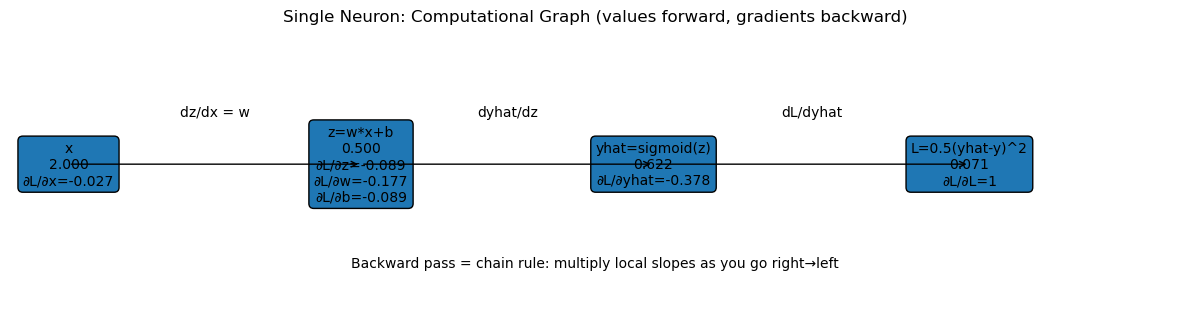



=== 2-LAYER NET: Forward values (one example) ===
x   = [ 1. -2.]
z1  = [ 0.3254  0.31   -0.6998]
a1  = [0.3254 0.31   0.    ]  (ReLU)
z2  = [-0.535]
yhat= [0.3694]
L   = 0.19885609520450773

=== 2-LAYER NET: Backward gradients (what you use to update params) ===
dL/dW2=
 [[-0.0478 -0.0455  0.    ]]
dL/db2= [-0.1469]
dL/dW1=
 [[ 0.0929 -0.1859]
 [ 0.0458 -0.0916]
 [ 0.      0.    ]]
dL/db1= [ 0.0929  0.0458 -0.    ]
dL/dx = [ 0.0205 -0.0037]


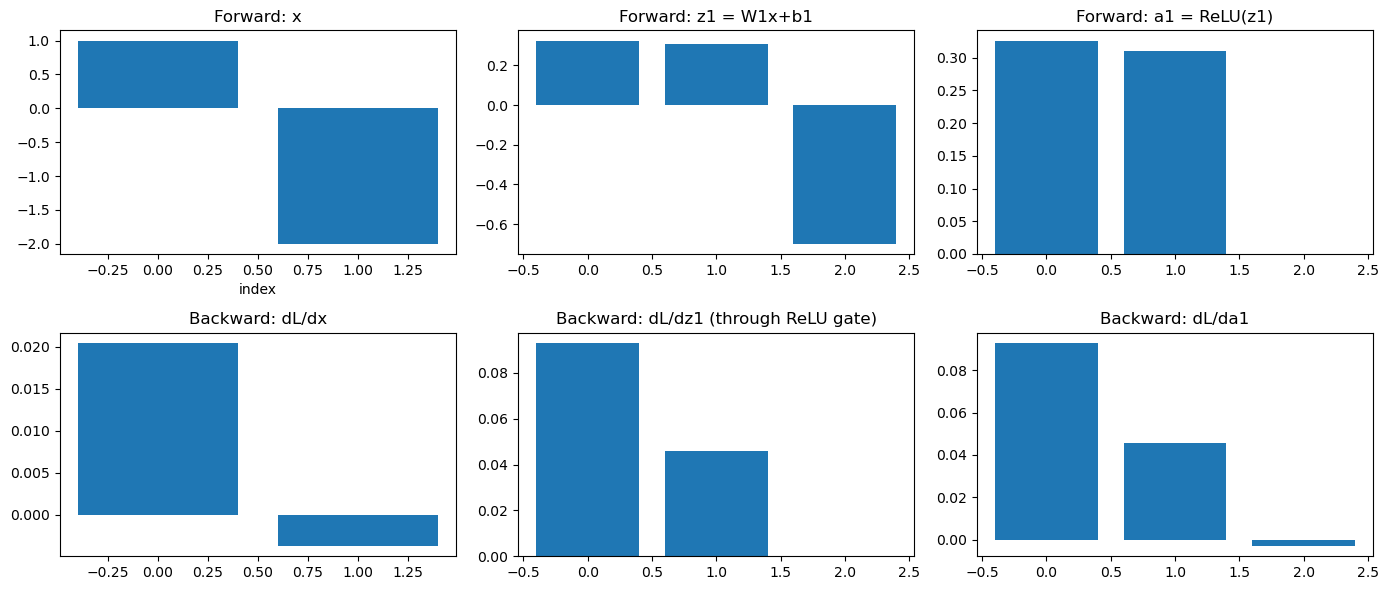

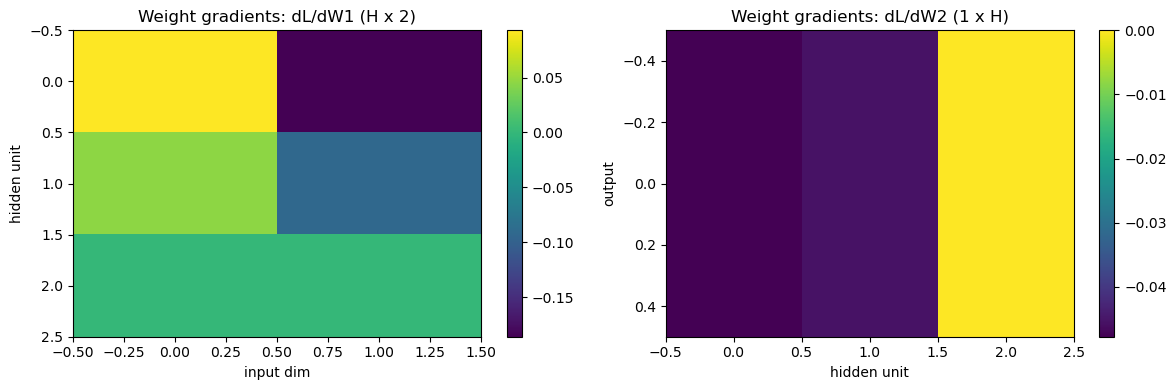


=== One training step (gradient descent) ===
Loss before: 0.19885609520450773
Loss after : 0.15626339867579583


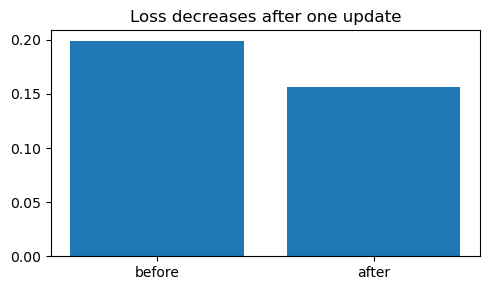

In [8]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

# -----------------------------
# Helpers: activations + loss
# -----------------------------
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def relu(z):
    return np.maximum(0, z)

def mse(yhat, y):
    return 0.5 * (yhat - y) ** 2  # 0.5 makes derivative cleaner

# -----------------------------
# Part A: Single neuron (scalar) — cleanest forward/backward demo
# yhat = sigmoid(w*x + b),  L = 0.5*(yhat - y)^2
# -----------------------------
def single_neuron_forward_backward(x, y, w, b):
    # forward
    z = w*x + b
    yhat = sigmoid(z)
    L = mse(yhat, y)

    # backward (chain rule)
    dL_dyhat = (yhat - y)                # d/dyhat of 0.5*(yhat-y)^2
    dyhat_dz = yhat * (1 - yhat)         # sigmoid'
    dL_dz = dL_dyhat * dyhat_dz

    dz_dw = x
    dz_db = 1.0
    dz_dx = w

    dL_dw = dL_dz * dz_dw
    dL_db = dL_dz * dz_db
    dL_dx = dL_dz * dz_dx

    cache = dict(x=x, y=y, z=z, yhat=yhat, L=L,
                 dL_dyhat=dL_dyhat, dyhat_dz=dyhat_dz, dL_dz=dL_dz,
                 dL_dw=dL_dw, dL_db=dL_db, dL_dx=dL_dx)
    return cache

# numeric gradient checker for scalar params
def numeric_grad_param(f, param_value, eps=1e-6):
    return (f(param_value + eps) - f(param_value - eps)) / (2*eps)

# choose numbers
x, y = 2.0, 1.0
w, b = 0.3, -0.1
cache = single_neuron_forward_backward(x, y, w, b)

# Print a "story" log
print("=== SINGLE NEURON: Forward pass (compute values) ===")
print(f"x={cache['x']}, y={cache['y']}")
print(f"z = w*x + b = {w}*{x} + {b} = {cache['z']:.6f}")
print(f"yhat = sigmoid(z) = {cache['yhat']:.6f}")
print(f"L = 0.5*(yhat - y)^2 = {cache['L']:.6f}")

print("\n=== SINGLE NEURON: Backward pass (compute gradients) ===")
print(f"dL/dyhat = (yhat - y) = {cache['dL_dyhat']:.6f}")
print(f"dyhat/dz = yhat*(1-yhat) = {cache['dyhat_dz']:.6f}")
print(f"dL/dz = (dL/dyhat)*(dyhat/dz) = {cache['dL_dz']:.6f}")
print(f"dL/dw = (dL/dz)*x = {cache['dL_dw']:.6f}")
print(f"dL/db = (dL/dz)*1 = {cache['dL_db']:.6f}")
print(f"dL/dx = (dL/dz)*w = {cache['dL_dx']:.6f}")

# Gradient check (w and b)
def loss_w(w_):
    z_ = w_*x + b
    yhat_ = sigmoid(z_)
    return mse(yhat_, y)

def loss_b(b_):
    z_ = w*x + b_
    yhat_ = sigmoid(z_)
    return mse(yhat_, y)

print("\n=== Gradient check (numeric vs backprop) ===")
print("dL/dw backprop :", cache["dL_dw"])
print("dL/dw numeric  :", numeric_grad_param(loss_w, w))
print("dL/db backprop :", cache["dL_db"])
print("dL/db numeric  :", numeric_grad_param(loss_b, b))

# Visualize the scalar computational graph as boxes + arrows
fig = plt.figure(figsize=(12, 3.2))
ax = fig.add_subplot(1, 1, 1)
ax.set_title("Single Neuron: Computational Graph (values forward, gradients backward)")
ax.axis("off")

pos = {"x": (0.05, 0.5), "z": (0.30, 0.5), "yhat": (0.55, 0.5), "L": (0.82, 0.5)}
def box(xy, text):
    ax.text(xy[0], xy[1], text, ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.35"))

def arrow(a, b, label=""):
    ax.annotate("", xy=pos[b], xytext=pos[a], arrowprops=dict(arrowstyle="->"))
    mid = ((pos[a][0]+pos[b][0])/2, (pos[a][1]+pos[b][1])/2)
    if label:
        ax.text(mid[0], mid[1]+0.18, label, ha="center")

box(pos["x"], f"x\n{cache['x']:.3f}\n∂L/∂x={cache['dL_dx']:.3f}")
box(pos["z"], f"z=w*x+b\n{cache['z']:.3f}\n∂L/∂z={cache['dL_dz']:.3f}\n∂L/∂w={cache['dL_dw']:.3f}\n∂L/∂b={cache['dL_db']:.3f}")
box(pos["yhat"], f"yhat=sigmoid(z)\n{cache['yhat']:.3f}\n∂L/∂yhat={cache['dL_dyhat']:.3f}")
box(pos["L"], f"L=0.5(yhat-y)^2\n{cache['L']:.3f}\n∂L/∂L=1")

arrow("x", "z", "dz/dx = w")
arrow("z", "yhat", "dyhat/dz")
arrow("yhat", "L", "dL/dyhat")

ax.text(0.5, 0.12, "Backward pass = chain rule: multiply local slopes as you go right→left",
        ha="center")
plt.tight_layout()
plt.show()

# -----------------------------
# Part B: Tiny 2-layer network (vector) — like a real NN
# x (2,) -> hidden (3,) -> output (1,)
# z1=W1x+b1, a1=ReLU(z1), z2=W2a1+b2, yhat=sigmoid(z2), L=MSE
# -----------------------------
rng = np.random.default_rng(0)

# dimensions
D_in, H, D_out = 2, 3, 1

# one training example
xv = np.array([1.0, -2.0])
yv = np.array([1.0])

# initialize weights small
W1 = rng.normal(0, 0.5, size=(H, D_in))
b1 = rng.normal(0, 0.1, size=(H,))
W2 = rng.normal(0, 0.5, size=(D_out, H))
b2 = rng.normal(0, 0.1, size=(D_out,))

def forward(xv, yv, W1, b1, W2, b2):
    z1 = W1 @ xv + b1
    a1 = relu(z1)
    z2 = W2 @ a1 + b2
    yhat = sigmoid(z2)
    L = mse(yhat, yv).item()
    cache = {"x": xv, "y": yv, "z1": z1, "a1": a1, "z2": z2, "yhat": yhat, "L": L}
    return cache

def backward(cache, W2):
    x = cache["x"]; y = cache["y"]
    z1 = cache["z1"]; a1 = cache["a1"]
    z2 = cache["z2"]; yhat = cache["yhat"]

    # dL/dyhat
    dL_dyhat = (yhat - y)  # shape (1,)
    # dyhat/dz2 (sigmoid')
    dyhat_dz2 = yhat * (1 - yhat)  # shape (1,)
    dL_dz2 = dL_dyhat * dyhat_dz2  # shape (1,)

    # z2 = W2 a1 + b2
    dL_dW2 = dL_dz2.reshape(-1,1) @ a1.reshape(1,-1)        # (1,H)
    dL_db2 = dL_dz2.copy()                                  # (1,)
    dL_da1 = (W2.T @ dL_dz2).reshape(-1)                     # (H,)

    # a1 = ReLU(z1)
    da1_dz1 = (z1 > 0).astype(float)                         # (H,)
    dL_dz1 = dL_da1 * da1_dz1                                # (H,)

    # z1 = W1 x + b1
    dL_dW1 = dL_dz1.reshape(-1,1) @ x.reshape(1,-1)          # (H,2)
    dL_db1 = dL_dz1.copy()                                   # (H,)
    dL_dx = W1.T @ dL_dz1                                    # (2,)

    grads = {"dL_dW2": dL_dW2, "dL_db2": dL_db2,
             "dL_dW1": dL_dW1, "dL_db1": dL_db1, "dL_dx": dL_dx,
             "dL_dz2": dL_dz2, "dL_da1": dL_da1, "dL_dz1": dL_dz1}
    return grads

cache2 = forward(xv, yv, W1, b1, W2, b2)
grads2 = backward(cache2, W2)

print("\n\n=== 2-LAYER NET: Forward values (one example) ===")
print("x   =", cache2["x"])
print("z1  =", cache2["z1"])
print("a1  =", cache2["a1"], " (ReLU)")
print("z2  =", cache2["z2"])
print("yhat=", cache2["yhat"])
print("L   =", cache2["L"])

print("\n=== 2-LAYER NET: Backward gradients (what you use to update params) ===")
print("dL/dW2=\n", grads2["dL_dW2"])
print("dL/db2=", grads2["dL_db2"])
print("dL/dW1=\n", grads2["dL_dW1"])
print("dL/db1=", grads2["dL_db1"])
print("dL/dx =", grads2["dL_dx"])

# Visuals: forward activations + backward gradients as bar charts, weight grads as heatmaps
fig = plt.figure(figsize=(14, 6))

# Forward bars
ax = fig.add_subplot(2, 3, 1)
ax.bar(np.arange(len(cache2["x"])), cache2["x"])
ax.set_title("Forward: x")
ax.set_xlabel("index")

ax = fig.add_subplot(2, 3, 2)
ax.bar(np.arange(len(cache2["z1"])), cache2["z1"])
ax.set_title("Forward: z1 = W1x+b1")

ax = fig.add_subplot(2, 3, 3)
ax.bar(np.arange(len(cache2["a1"])), cache2["a1"])
ax.set_title("Forward: a1 = ReLU(z1)")

# Backward bars
ax = fig.add_subplot(2, 3, 4)
ax.bar(np.arange(len(grads2["dL_dx"])), grads2["dL_dx"])
ax.set_title("Backward: dL/dx")

ax = fig.add_subplot(2, 3, 5)
ax.bar(np.arange(len(grads2["dL_dz1"])), grads2["dL_dz1"])
ax.set_title("Backward: dL/dz1 (through ReLU gate)")

ax = fig.add_subplot(2, 3, 6)
ax.bar(np.arange(len(grads2["dL_da1"])), grads2["dL_da1"])
ax.set_title("Backward: dL/da1")

plt.tight_layout()
plt.show()

fig = plt.figure(figsize=(12, 4))
ax = fig.add_subplot(1, 2, 1)
im = ax.imshow(grads2["dL_dW1"], aspect="auto")
ax.set_title("Weight gradients: dL/dW1 (H x 2)")
ax.set_xlabel("input dim"); ax.set_ylabel("hidden unit")
plt.colorbar(im, ax=ax)

ax = fig.add_subplot(1, 2, 2)
im2 = ax.imshow(grads2["dL_dW2"], aspect="auto")
ax.set_title("Weight gradients: dL/dW2 (1 x H)")
ax.set_xlabel("hidden unit"); ax.set_ylabel("output")
plt.colorbar(im2, ax=ax)

plt.tight_layout()
plt.show()

# Show 1 gradient descent step to make it feel real
lr = 0.5
W1_new = W1 - lr * grads2["dL_dW1"]
b1_new = b1 - lr * grads2["dL_db1"]
W2_new = W2 - lr * grads2["dL_dW2"]
b2_new = b2 - lr * grads2["dL_db2"]

cache_before = cache2
cache_after = forward(xv, yv, W1_new, b1_new, W2_new, b2_new)

print("\n=== One training step (gradient descent) ===")
print("Loss before:", cache_before["L"])
print("Loss after :", cache_after["L"])

# Simple visual: loss before vs after
fig = plt.figure(figsize=(5, 3))
ax = fig.add_subplot(1, 1, 1)
ax.bar([0, 1], [cache_before["L"], cache_after["L"]])
ax.set_xticks([0, 1], ["before", "after"])
ax.set_title("Loss decreases after one update")
plt.tight_layout()
plt.show()


In [9]:
import math

x, y = 2.0, 1.0
w, b = 0.3, -0.1

sigmoid = lambda z: 1/(1+math.exp(-z))

# forward
z = w*x + b
yhat = sigmoid(z)
L = -(y*math.log(yhat) + (1-y)*math.log(1-yhat))

# backward (sigmoid + cross entropy)
dL_dz = yhat - y
dL_dw = dL_dz * x
dL_db = dL_dz

print("z =", z)
print("yhat =", yhat)
print("L =", L)
print("dL/dz =", dL_dz)
print("dL/dw =", dL_dw)
print("dL/db =", dL_db)

# update
lr = 0.1
w2 = w - lr*dL_dw
b2 = b - lr*dL_db

z2 = w2*x + b2
yhat2 = sigmoid(z2)
L2 = -(y*math.log(yhat2) + (1-y)*math.log(1-yhat2))

print("\nAfter one update:")
print("w2, b2 =", w2, b2)
print("L2 =", L2)


z = 0.5
yhat = 0.6224593312018546
L = 0.47407698418010663
dL/dz = -0.3775406687981454
dL/dw = -0.7550813375962908
dL/db = -0.3775406687981454

After one update:
w2, b2 = 0.3755081337596291 -0.06224593312018546
L2 = 0.4069261863938286


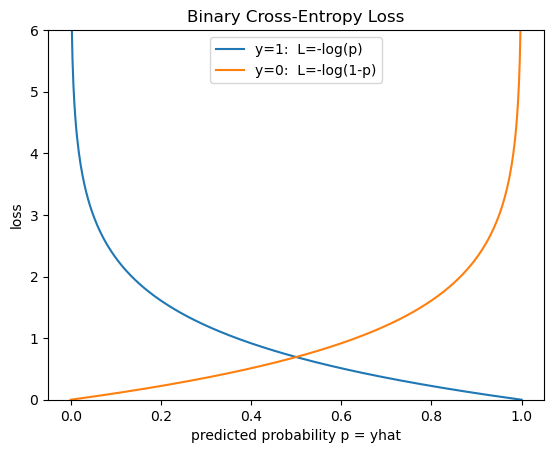

In [10]:
import numpy as np
import matplotlib.pyplot as plt

p = np.linspace(1e-6, 1-1e-6, 500)

loss_y1 = -np.log(p)         # when y=1
loss_y0 = -np.log(1-p)       # when y=0

plt.plot(p, loss_y1, label="y=1:  L=-log(p)")
plt.plot(p, loss_y0, label="y=0:  L=-log(1-p)")
plt.xlabel("predicted probability p = yhat")
plt.ylabel("loss")
plt.title("Binary Cross-Entropy Loss")
plt.legend()
plt.ylim(0, 6)
plt.show()
